### The first step to identifying good voxel regions is to visualize the density grid exported by Instant NGP

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pyvista as pv

def load_volume_from_png(png_path, volume_resolution=256, slice_grid_size=32):
    print(f"Loading volume from: {png_path}")
    Image.MAX_IMAGE_PIXELS = None  # Disable the limit to prevent compression bomb-related error
    img = Image.open(png_path)
    img_array = np.array(img)
    
    if len(img_array.shape) == 3:  # RGB image
        # Convert to grayscale by taking the first channel
        img_array = img_array[:,:,0]
    
    img_height, img_width = img_array.shape
    print(f"Image dimensions: {img_width}x{img_height}")
    
    slice_pixel_size = img_width // slice_grid_size
    print(f"Each slice is {slice_pixel_size}x{slice_pixel_size} pixels")
    
    volume = np.zeros((volume_resolution, volume_resolution, volume_resolution), dtype=np.float32)
    
    scale_factor = volume_resolution / slice_pixel_size
    
    # Parse the PNG into slices and arrange them into the 3D volume
    slice_counter = 0
    for y_tile in range(slice_grid_size):
        for x_tile in range(slice_grid_size):
            # Skip if we've already filled the volume
            if slice_counter >= volume_resolution:
                break
                
            # Extract the current slice
            y_start = y_tile * slice_pixel_size
            y_end = (y_tile + 1) * slice_pixel_size
            x_start = x_tile * slice_pixel_size
            x_end = (x_tile + 1) * slice_pixel_size
            
            current_slice = img_array[y_start:y_end, x_start:x_end]
            
            # Resize the slice if necessary to match the volume resolution
            if scale_factor != 1:
                from scipy.ndimage import zoom
                current_slice = zoom(current_slice, (scale_factor, scale_factor), order=1)
            
            # Place the slice in the 3D volume
            # The slices are ordered from bottom to top along the Z axis
            volume[:, :, slice_counter] = current_slice
            slice_counter += 1
            
        if slice_counter >= volume_resolution:
            break
            
    print(f"Loaded {slice_counter} Z-slices into the volume")
    
    # Normalize the volume to [0, 1] range
    volume = volume / 255.0
    
    return volume

def visualize_volume_3d(volume, opacity_mapping='linear', cmap="viridis", background_color="white"):    
    # Create a uniform grid for the data
    dims = np.array(volume.shape) + 1
    grid = pv.ImageData()
    grid.dimensions = dims
    
    # Center the grid at the origin
    grid.origin = [-s/2 for s in volume.shape]
    grid.spacing = (1, 1, 1)
    
    grid.cell_data["density"] = volume.flatten(order='F')
    
    # Create a plotter
    plotter = pv.Plotter()
    plotter.set_background(background_color)
    plotter.add_axes()
    plotter.add_bounding_box()
    plotter.add_volume(grid, cmap=cmap, opacity=opacity_mapping, clim=[0, volume.max()])
    
    return plotter

def visualize_volume_slices(volume, z_indices=None, num_slices=4, figsize=(15, 10)):
    if z_indices is None:
        z_indices = np.linspace(0, volume.shape[2]-1, num_slices, dtype=int)
    
    fig, axes = plt.subplots(1, len(z_indices), figsize=figsize)
    if len(z_indices) == 1:
        axes = [axes]
    
    for i, z_idx in enumerate(z_indices):
        im = axes[i].imshow(volume[:, :, z_idx].T, origin='lower', cmap='viridis')
        axes[i].set_title(f'Z-Slice {z_idx}')
        fig.colorbar(im, ax=axes[i])
    
    plt.tight_layout()
    plt.show()

def transform_volume(volume, normalize=True, invert=False, threshold = 0.1):
        # Create a copy to avoid modifying the original
        transformed = volume.copy()
        
        # Normalize to 0-1 range if requested
        if normalize:
            min_val = transformed.min()
            max_val = transformed.max()
            if min_val < 0 or max_val > 1:
                transformed = (transformed - min_val) / (max_val - min_val)
        
        # Invert densities if requested (make low density visible, high density transparent)
        if invert:
            transformed = 1 - transformed
        
        transformed[transformed < threshold] = 0
        return transformed

def explore_volume(png_path, volume_resolution=256, slice_grid_size=32, threshold = 0.1, invert = False):
    # Load the volume
    volume = load_volume_from_png(png_path, volume_resolution, slice_grid_size)
    volume = transform_volume(volume, invert=invert, threshold=threshold)
    print(f"Volume shape: {volume.shape}")
    print(f"Min density: {volume.min():.4f}, Max density: {volume.max():.4f}")
    
    # Show some slices
    print("Displaying Z-slices of the volume:")
    visualize_volume_slices(volume, z_indices=[int(volume_resolution*0.25), 
                                             int(volume_resolution*0.5), 
                                             int(volume_resolution*0.75)])
    
    # Create 3D visualization with PyVista
    print("Preparing 3D visualization...")
    plotter = visualize_volume_3d(volume, opacity_mapping='linear')
    
    # Display the 3D visualization
    print("Displaying 3D visualization (you can interact with this window):")
    plotter.show()
    
    return volume, plotter

Loading volume from: ./chess.density_slices_576x576x576.png
Image dimensions: 13824x13824
Each slice is 576x576 pixels
Loaded 576 Z-slices into the volume
Volume shape: (576, 576, 576)
Min density: 0.0000, Max density: 1.0000
Displaying Z-slices of the volume:


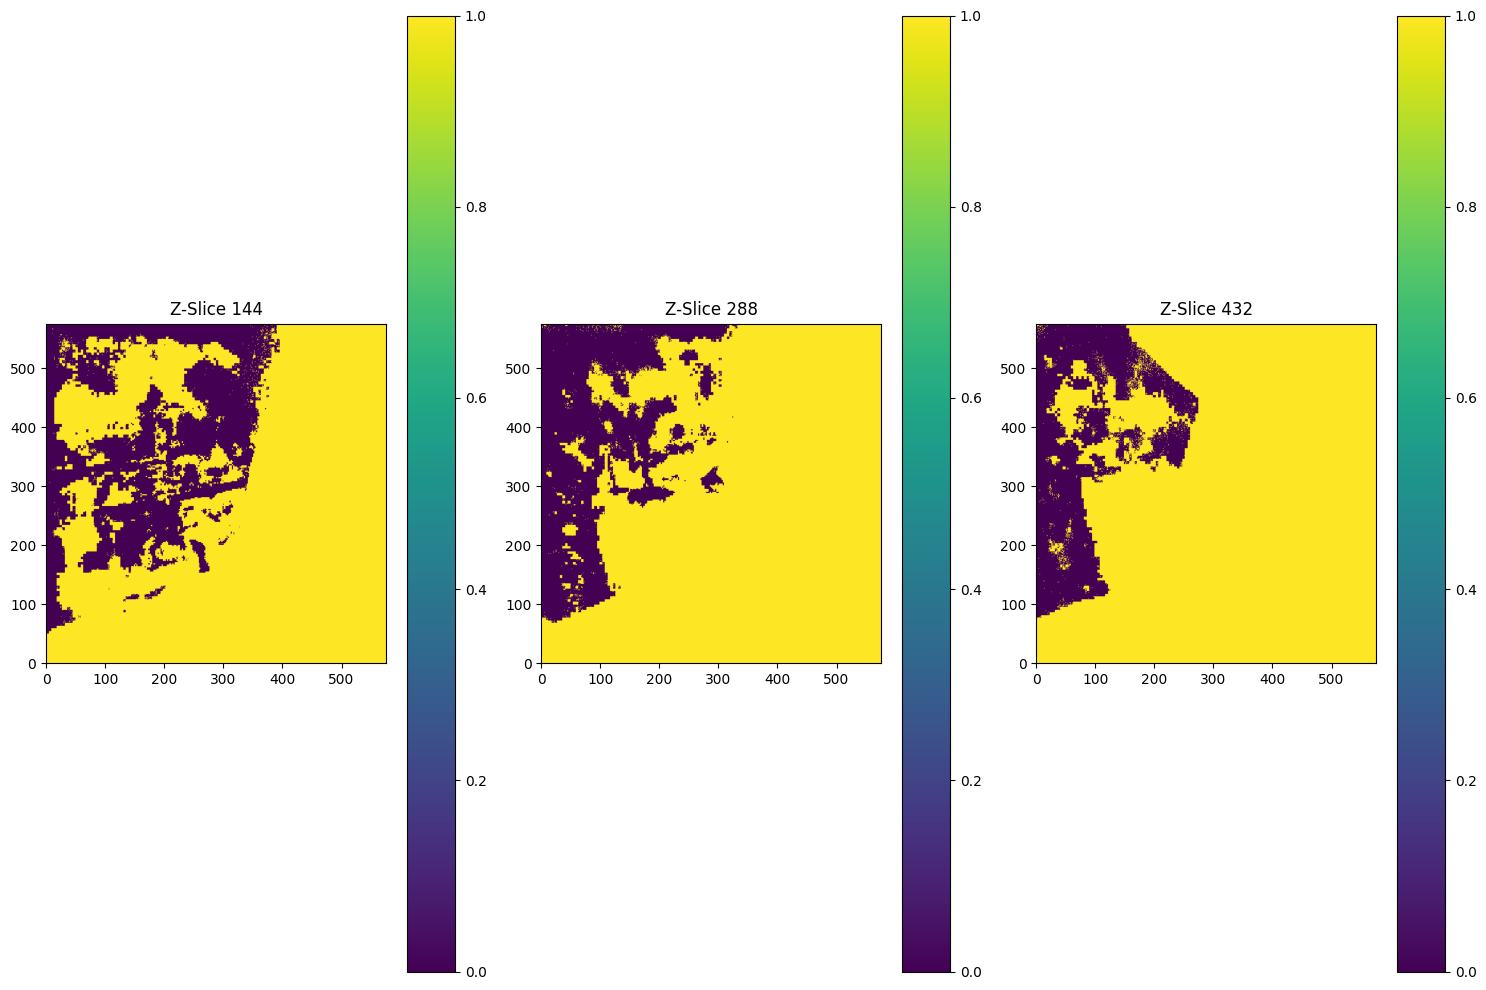

Preparing 3D visualization...
Displaying 3D visualization (you can interact with this window):


Widget(value='<iframe src="http://localhost:50517/index.html?ui=P_0x3169d0690_4&reconnect=auto" class="pyvista…

In [ ]:
png_path = "./chess.density_slices_576x576x576.png" 

volume, plotter = explore_volume(
    png_path=png_path, 
    volume_resolution=576,  # The resolution of the volume (256x256x256)
    slice_grid_size=24,      
    threshold=0.9,          # Minimum density value to display
    invert=True            # Invert the densities for better visibility
)

## Let's Check out a Downsampling of our volume...

Original volume shape: (576, 576, 576)
Downsampled volume shape: (64, 64, 64)


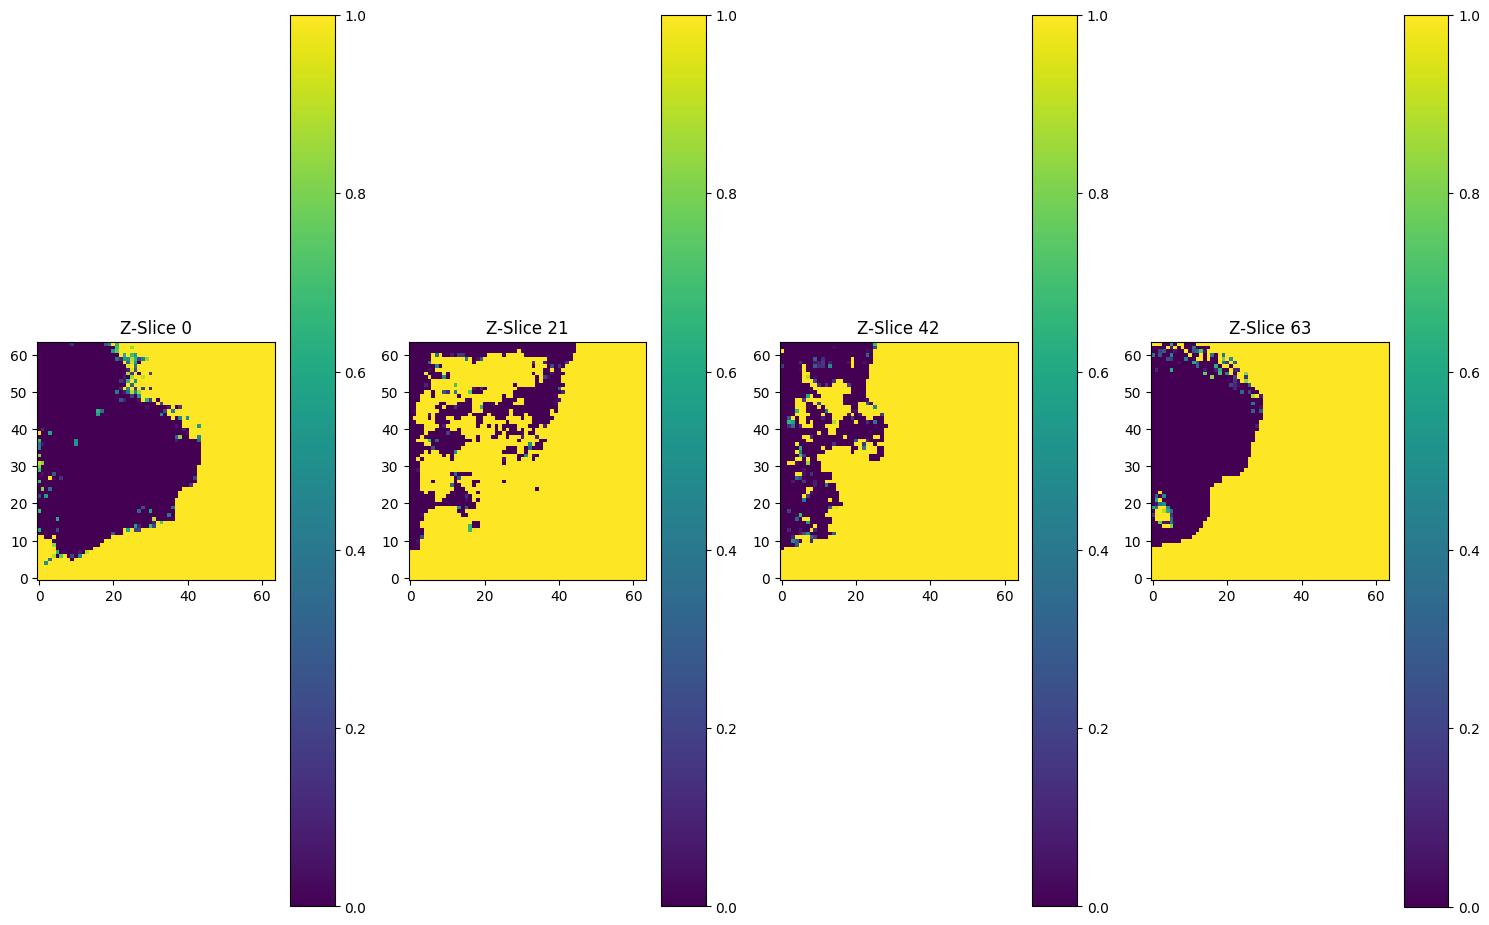

Widget(value='<iframe src="http://localhost:50517/index.html?ui=P_0x31a5020d0_5&reconnect=auto" class="pyvista…

In [ ]:
from scipy.ndimage import zoom

desired_resolution = 64

zoom_factors = (desired_resolution / volume.shape[0], desired_resolution / volume.shape[1], desired_resolution / volume.shape[2])
downsampled_volume = zoom(volume, zoom_factors, order=1)  # order=1 for linear interpolation

print(f"Original volume shape: {volume.shape}")
print(f"Downsampled volume shape: {downsampled_volume.shape}")

visualize_volume_slices(downsampled_volume, num_slices=4, figsize=(15, 10))

plotter = visualize_volume_3d(downsampled_volume, opacity_mapping='linear')
plotter.show()

## Okay lets try spectral clustering on the sparse volume

In [ ]:
from scipy.sparse import coo_matrix
volume=downsampled_volume
voxels = volume.flatten()
voxel_indices = np.arange(voxels.size) # Voxel indices in linear order
valid_indices = voxel_indices[voxels > 0] # Indices of non-zero voxels
valid_voxels = voxels[voxels > 0] # Non-zero voxel values

def index_to_3d(index, shape):
    z = index // (shape[0] * shape[1])
    y = (index % (shape[0] * shape[1])) // shape[0]
    x = index % shape[0]
    return x, y, z

# Define the 6 neighbors for each voxel
neighbors = [
    (1, 0, 0),  # Right
    (-1, 0, 0),  # Left
    (0, 1, 0),  # Up
    (0, -1, 0),  # Down
    (0, 0, 1),  # Front
    (0, 0, -1)  # Back
]

valid_indices_3d = np.array([index_to_3d(index, volume.shape) for index in valid_indices])  # Convert valid indices to 3D coordinates
print("Valid indices shape:", valid_indices_3d.shape)

neighbor_offsets = np.array(neighbors) 
all_neighbor_coords = valid_indices_3d[:, np.newaxis, :] + neighbor_offsets  # Add neighbor offsets to all valid coordinates
print("All neighbor coordinates shape:", all_neighbor_coords.shape)

valid_neighbors_mask = np.all((all_neighbor_coords >= 0) & (all_neighbor_coords < np.array(volume.shape)), axis=2)
print("Valid neighbors mask shape:", valid_neighbors_mask.shape)

# Convert valid neighbor coordinates back to linear indices
valid_neighbor_indices = np.array([np.ravel_multi_index(coord, volume.shape) if valid else -1 
                                   for coord, valid in zip(all_neighbor_coords.reshape(-1, 3), valid_neighbors_mask.reshape(-1))]).reshape(len(valid_indices), len(neighbors))
print("Valid neighbor indices shape:", valid_neighbor_indices.shape)

N = len(valid_indices)
sorted_valid_indices = np.sort(valid_indices)
# Create a map from original volume index to its position in the sorted array (0 to N-1)

# 2. Flatten neighbor indices and create corresponding row indices (0 to N-1)
flat_neighbor_indices = valid_neighbor_indices.ravel() # Shape (N*6,)
row_indices = np.repeat(np.arange(N), 6) # Shape (N*6,)

# 3. Filter out neighbors that are outside the volume bounds (marked as -1 earlier)
#    Also filter out neighbors that are not in the valid set using np.isin ONCE
valid_mask = (flat_neighbor_indices != -1) & np.isin(flat_neighbor_indices, sorted_valid_indices, assume_unique=True)

# 4. Keep only the valid connections
final_rows = row_indices[valid_mask]
final_original_neighbor_indices = flat_neighbor_indices[valid_mask]

# 5. Map the original volume indices of the neighbors to the new indices (0 to N-1)
#    using the sorted array for efficient lookup.
final_cols = np.searchsorted(sorted_valid_indices, final_original_neighbor_indices)

# 6. Define data for the sparse matrix (unweighted edges)
data = np.ones_like(final_rows, dtype=np.int8) # Use smaller dtype if possible

print("Creating sparse matrix...")
adjacency_matrix_sparse = coo_matrix((data, (final_rows, final_cols)), shape=(N, N))

djacency_matrix_sparse = adjacency_matrix_sparse.tocsr()

# ---- START MANUAL SPECTRAL CLUSTERING ----
print("Performing manual spectral clustering using sparse matrices...")
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans

n_clusters = 10 # Define the number of clusters

# 1. Calculate the graph Laplacian (Normalized is often better)

# guarunteeing symmetry
adjacency_matrix_sparse = (adjacency_matrix_sparse + adjacency_matrix_sparse.T) / 2

print("Calculating Laplacian...")
lap, dd = laplacian(adjacency_matrix_sparse, normed=True, return_diag=True)

# 2. Compute eigenvectors using sparse eigensolver (ARPACK)
#    We want the eigenvectors corresponding to the smallest eigenvalues.
#    'SM' means smallest magnitude.
#    We need k eigenvectors (n_clusters). 
print(f"Calculating {n_clusters} eigenvectors...")

k_eig = min(n_clusters, N - 2) # Cannot compute N eigenvectors, Ensure k is less than N-1 for eigsh
if k_eig < n_clusters:
    print(f"Warning: Requested {n_clusters} clusters, but can only compute {k_eig} eigenvectors for stability. Reducing cluster count.")
    n_clusters = k_eig

try:
    # Find k_eig eigenvectors corresponding to the smallest eigenvalues
    eigenvalues, eigenvectors = eigsh(lap, k=k_eig, which='SM', tol=1e-3)
    print(f"Eigenvectors shape: {eigenvectors.shape}")
except Exception as e:
    print(f"Eigenvalue computation failed: {e}")
    print("Try reducing n_clusters or check matrix properties.")
    raise e

print("Running KMeans on eigenvectors...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init='auto' in newer sklearn
kmeans.fit(eigenvectors)
labels = kmeans.labels_


print("Creating label volume...")
# Create a label volume, mapping labels back to original indices
label_volume = np.zeros_like(volume, dtype=int)
# Map labels (0 to n_clusters-1) back to the original sorted_valid_indices
# We add 1 to labels so cluster IDs start from 1 (0 means background)
label_map = {original_idx: label + 1 for original_idx, label in zip(sorted_valid_indices, labels)}

# Assign cluster labels to the original volume using the map
for index in valid_indices: # Iterate through original valid_indices
    if index in label_map: # Check if the index was part of the clustered graph
        x, y, z = index_to_3d(index, volume.shape)
        label_volume[x, y, z] = label_map[index] # Assign cluster label (1 to n_clusters)

print("Visualizing clustered volume slices...")
# Visualize the clustered volume slices (using a qualitative cmap)
visualize_volume_slices(label_volume, num_slices=4, figsize=(15, 10)) # Keep this for 2D view

print("Preparing 3D visualization with toggleable clusters...")

# ---- START MODIFIED 3D VISUALIZATION ----

# 1. Create the PyVista grid object containing the label data
dims = np.array(label_volume.shape) + 1
grid = pv.ImageData()
grid.dimensions = dims
grid.origin = [-s/2 for s in label_volume.shape] # Center the grid
grid.spacing = (1, 1, 1)
# Assign labels to cell data. Use 'F' order for Fortran/column-major like volume data
grid.cell_data["labels"] = label_volume.flatten(order='F')

# 2. Create a plotter
plotter = pv.Plotter() # Use notebook=False for interactive window
plotter.set_background("white")
plotter.add_axes()
plotter.add_bounding_box()

# 3. Define a qualitative colormap and opacity
#    Get unique cluster labels present in the volume (excluding 0)
unique_labels = np.unique(label_volume)
unique_labels = unique_labels[unique_labels > 0] # Exclude background label 0
cmap = plt.get_cmap("tab10", len(unique_labels)) # Get a colormap with enough distinct colors
uniform_opacity = 0.5 # Set desired uniform opacity

# 4. Add each cluster as a separate mesh
for i, label_id in enumerate(unique_labels):
    # Extract the mesh for the current cluster label
    # Threshold values between label_id-0.5 and label_id+0.5 to isolate the integer label
    cluster_mesh = grid.threshold([label_id - 0.5, label_id + 0.5], scalars="labels")

    # Check if the mesh is not empty before adding
    if cluster_mesh.n_cells > 0:
        cluster_color = cmap(i) # Get color from the colormap index
        actor_name = f"Cluster {label_id}"
        plotter.add_mesh(
            cluster_mesh,
            color=cluster_color,
            opacity=uniform_opacity,
            name=actor_name,
            show_scalar_bar=False # No need for a scalar bar for each cluster
        )
        print(f"Added {actor_name} with color {cluster_color}")
    else:
        print(f"Skipped Cluster {label_id} (no cells found after thresholding)")


# 5. Show the plot
print("Displaying 3D visualization. Use the interactive window controls to toggle clusters.")
# You might be able to toggle visibility using checkboxes or a dropdown in the render window
# depending on your PyVista backend and environment. Look for actor names like "Cluster 1", "Cluster 2", etc.
plotter.show()


NameError: name 'downsampled_volume' is not defined

Generating Perlin noise...
Noise generated and normalized.


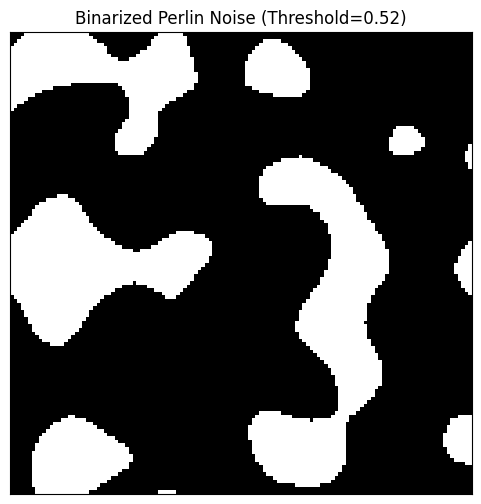

Building graph from white pixels...
Graph created with 4600 nodes and 17077 edges in 0.03 seconds.
Calculating force-directed layout (this may take a moment)...
Layout calculated in 25.54 seconds.


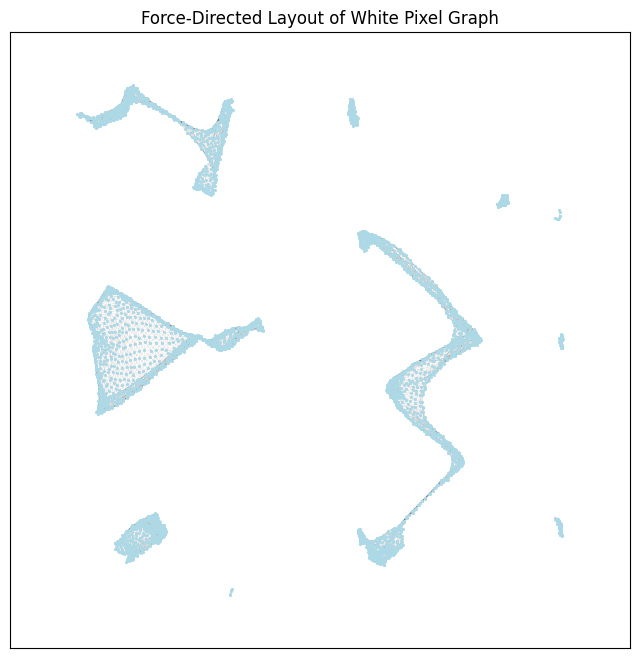

Performing spectral clustering...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Spectral clustering completed with 5 clusters.
Clustering finished in 0.54 seconds.


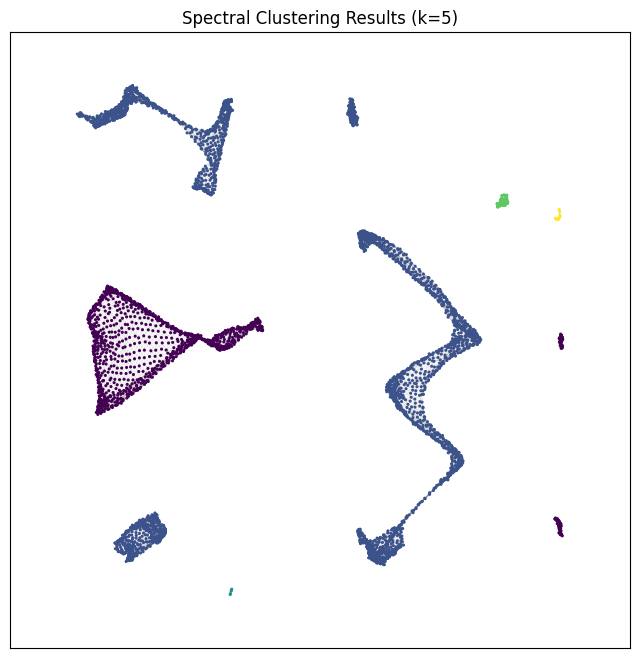

Rendering clustered image...


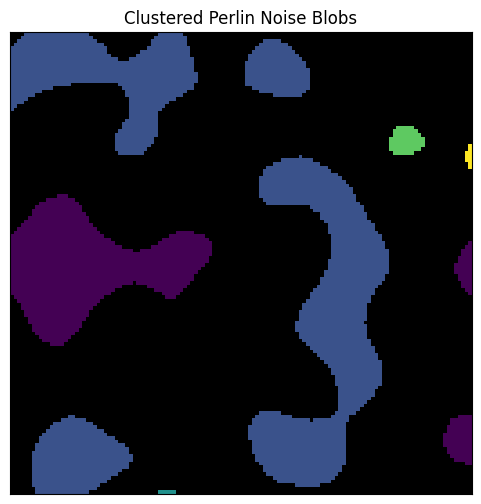

Done.


In [22]:
import numpy as np
from perlin_noise import PerlinNoise
import networkx as nx
from sklearn.cluster import SpectralClustering
from scipy.sparse import find
import time

import matplotlib.pyplot as plt

# Parameters
img_size = 128
noise_octaves = 5       # Controls detail level
noise_seed = 2
threshold = 0.52         # Binarization threshold (after normalizing noise to [0, 1])
n_clusters = 5          # Desired number of clusters
zoom_factor = 1         # Controls the "zoom" or scale of noise features

# 1. Generate Perlin Noise
print("Generating Perlin noise...")
noise = PerlinNoise(octaves=noise_octaves, seed=noise_seed)
noiseHF = PerlinNoise(octaves=noise_octaves, seed=noise_seed + 1) # For high frequency noise
pic = np.zeros((img_size, img_size))
for i in range(img_size):
    for j in range(img_size):
        # Scale coordinates by zoom_factor to get larger features
        pic[i][j] = noise([i / (img_size / zoom_factor), j / (img_size / zoom_factor)])
        


# Normalize noise to [0, 1] range
pic_min, pic_max = pic.min(), pic.max()
if pic_max > pic_min:
    pic = (pic - pic_min) / (pic_max - pic_min)
else:
    pic = np.zeros_like(pic) # Handle case of flat noise (unlikely with Perlin)
print("Noise generated and normalized.")

# 2. Binarize
binary_image = pic > threshold

# 3. Plot Binary Image
plt.figure(figsize=(6, 6))
plt.imshow(binary_image, cmap='gray')
plt.title(f'Binarized Perlin Noise (Threshold={threshold})')
plt.xticks([])
plt.yticks([])
plt.show()

# 4. Build Graph from white pixels
print("Building graph from white pixels...")
start_time = time.time()
white_pixels = np.argwhere(binary_image) # Get coordinates (row, col) of white pixels
node_indices = {tuple(coord): i for i, coord in enumerate(white_pixels)} # Map coords to node index 0..N-1
num_nodes = len(white_pixels)

if num_nodes == 0:
    print("No white pixels found at the current threshold. Cannot build graph.")
else:
    G = nx.Graph()
    # Store positions using (col, -row) for standard plot orientation
    pos = {node_indices[tuple(coord)]: (coord[1], -coord[0]) for coord in white_pixels}
    G.add_nodes_from(range(num_nodes))

    # Add edges for 8-connectivity (neighbors including diagonals)
    for r, c in white_pixels:
        node_u = node_indices[(r, c)]
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue # Skip self
                nr, nc = r + dr, c + dc
                # Check if neighbor is within bounds and is also white
                if 0 <= nr < img_size and 0 <= nc < img_size and binary_image[nr, nc]:
                    node_v = node_indices[(nr, nc)]
                    # Add edge only once (e.g., if node_u < node_v) to avoid duplicates
                    if node_u < node_v:
                         G.add_edge(node_u, node_v)

    end_time = time.time()
    print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges in {end_time - start_time:.2f} seconds.")

    # 5. Force-Directed Layout
    print("Calculating force-directed layout (this may take a moment)...")
    start_time = time.time()
    # Use spring_layout. Initial positions from 'pos' can sometimes help convergence.
    # Adjust k (optimal distance) and iterations as needed.
    pos_layout = nx.spring_layout(G, pos=pos, k=0.5/np.sqrt(num_nodes) if num_nodes > 0 else 0.1, iterations=50, seed=42)
    end_time = time.time()
    print(f"Layout calculated in {end_time - start_time:.2f} seconds.")


    # 6. Render Graph (Layout only)
    plt.figure(figsize=(8, 8))
    nx.draw_networkx_nodes(G, pos_layout, node_size=5, node_color='lightblue', linewidths=0)
    nx.draw_networkx_edges(G, pos_layout, alpha=0.1, width=0.5)
    plt.title('Force-Directed Layout of White Pixel Graph')
    plt.xticks([])
    plt.yticks([])
    plt.axis('equal')
    plt.show()

    # 7. Spectral Clustering
    print("Performing spectral clustering...")
    start_time = time.time()
    # Get the adjacency matrix in sparse format
    # Ensure nodelist is sorted to align with labels later
    node_list = sorted(G.nodes())
    adj_matrix = nx.adjacency_matrix(G, nodelist=node_list)

    labels = np.zeros(G.number_of_nodes(), dtype=int) # Default labels

    sc = SpectralClustering(
        n_clusters=n_clusters,
        affinity='precomputed', # We provide the adjacency matrix
        assign_labels='kmeans', # Common method to assign labels from eigenvectors
        random_state=42,
        n_init=10 # Number of times k-means runs with different seeds
    )
    # Ensure indices and indptr are int32 for scikit-learn compatibility
    # Check if it's a CSR or CSC matrix which have these attributes
    if hasattr(adj_matrix, 'indices') and hasattr(adj_matrix, 'indptr'):
            # Check dtype before converting to avoid unnecessary operations
            if adj_matrix.indices.dtype != np.int32:
                adj_matrix.indices = adj_matrix.indices.astype(np.int32)
            if adj_matrix.indptr.dtype != np.int32:
                adj_matrix.indptr = adj_matrix.indptr.astype(np.int32)
    # Check for COO format as well, which has 'row' and 'col'
    elif hasattr(adj_matrix, 'row') and hasattr(adj_matrix, 'col'):
            if adj_matrix.row.dtype != np.int32:
                adj_matrix.row = adj_matrix.row.astype(np.int32)
            if adj_matrix.col.dtype != np.int32:
                adj_matrix.col = adj_matrix.col.astype(np.int32)

    # Now fit_predict should work
    labels = sc.fit_predict(adj_matrix)
        
    print(f"Spectral clustering completed with {n_clusters} clusters.")


    end_time = time.time()
    print(f"Clustering finished in {end_time - start_time:.2f} seconds.")

    # 8. Render Graph (Clustered)
    plt.figure(figsize=(8, 8))
    # Use a qualitative colormap suitable for clusters
    cmap = plt.get_cmap('viridis', n_clusters)
    nx.draw_networkx_nodes(G, pos_layout, node_size=5, node_color=labels, cmap=cmap, linewidths=0)
    nx.draw_networkx_edges(G, pos_layout, alpha=0.1, width=0.5)
    plt.title(f'Spectral Clustering Results (k={n_clusters})')
    plt.xticks([])
    plt.yticks([])
    plt.axis('equal') # Keep aspect ratio
    plt.show()

    # 9. Render Clustered Image
    print("Rendering clustered image...")
    # Start with a black background
    clustered_image = np.zeros((img_size, img_size, 3)) # RGB image (values 0-1)

    # Get colors from the colormap
    colors = cmap(np.linspace(0, 1, n_clusters))[:, :3] # Get RGB components

    # Map node indices back to coordinates and assign colors
    coords_map = {v: k for k, v in node_indices.items()} # Reverse mapping: node_id -> (r, c)

    for i, node_id in enumerate(node_list): # Iterate through sorted nodes to match labels
        r, c = coords_map[node_id]
        cluster_label = labels[i]
        clustered_image[r, c] = colors[cluster_label]

    plt.figure(figsize=(6, 6))
    plt.imshow(clustered_image)
    plt.title('Clustered Perlin Noise Blobs')
    plt.xticks([])
    plt.yticks([])
    plt.show()
    print("Done.")

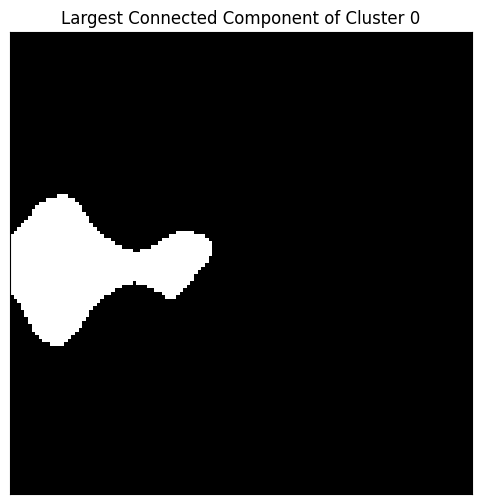

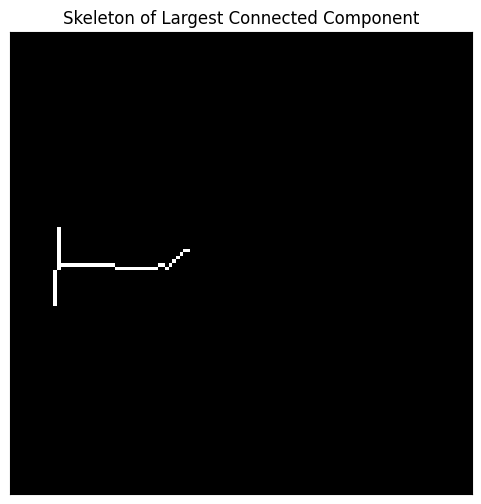

Rightmost pixel in skeleton: (np.int64(60), np.int64(49))


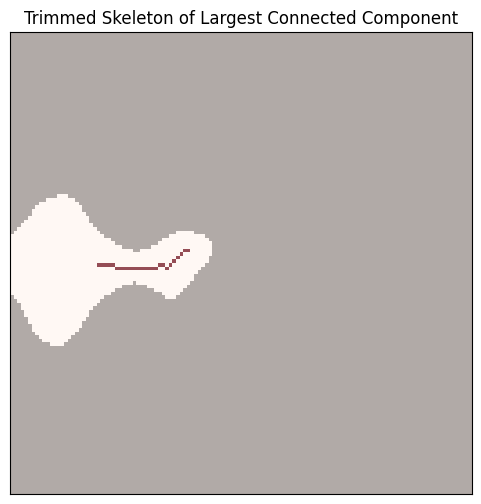

In [68]:
import networkx as nx
import numpy as np
from scipy import ndimage
from skimage.morphology import skeletonize 

import matplotlib.pyplot as plt

# 1. Isolate Target Cluster
target_cluster_id = 0  # Cluster IDs start from 0
# Initialize a boolean array to hold the cluster membership
target_cluster_mask = np.zeros(num_nodes, dtype=bool)

# Iterate through the 'labels' array and set the corresponding element in 'target_cluster_mask' to True if the label matches the 'target_cluster_id'
for i, label in enumerate(labels):
    if label == target_cluster_id:
        target_cluster_mask[i] = True
# Create a binary image where the target cluster is white and the rest is black
target_cluster_image = np.zeros_like(binary_image, dtype=bool)

# Map node indices back to coordinates and assign colors
coords_map = {v: k for k, v in node_indices.items()} # Reverse mapping: node_id -> (r, c)

# Iterate through the nodes and if the node belongs to the target cluster,
# set the corresponding pixel in the target_cluster_image to True (white)
for i, node_id in enumerate(node_list):
    if target_cluster_mask[i]:
        r, c = coords_map[node_id]
        target_cluster_image[r, c] = True

# 2. Find Largest Connected Component
# Label connected regions in the binary image
labeled_image, num_labels = ndimage.label(target_cluster_image)

# If no components are found, return early
if num_labels == 0:
    print("No connected components found for the target cluster.")
else:

    component_sizes = np.bincount(labeled_image.flatten())
    component_sizes[0] = 0
    largest_component_label = np.argmax(component_sizes)
    largest_component = (labeled_image == largest_component_label)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(largest_component, cmap='gray')
    plt.title(f'Largest Connected Component of Cluster {target_cluster_id}')
    plt.xticks([])
    plt.yticks([])
    plt.show()

    # 3. Erode to Skeleton
    # Perform skeletonization
    skeleton = skeletonize(largest_component)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(skeleton, cmap='gray')
    plt.title(f'Skeleton of Largest Connected Component')
    plt.xticks([])
    plt.yticks([])
    plt.show()
    
    # Find rightmost pixel in skeleton
    skeleton_pixels = np.argwhere(skeleton)
    if skeleton_pixels.size == 0:
        print("Skeleton is empty, cannot find rightmost pixel.")
    else:
        rightmost_pixel = tuple(skeleton_pixels[np.argmax(skeleton_pixels[:, 1])])
        print(f"Rightmost pixel in skeleton: {rightmost_pixel}")


    # traverse the skeleton starting at the rightmost pixel, adding pixels to a new "trimmed skeleton", colored by the order they were added, and terminating once a euclidean distance from the source right pixel is reached
    trimmed_skeleton = np.zeros_like(skeleton, dtype=bool)
    trimmed_skeleton[rightmost_pixel] = True
    current_pixel = rightmost_pixel
    distance_threshold = 25
    distance_traveled = 0
    visited = set()
    visited.add(current_pixel)
    
    # Define a helper function to get valid neighbors
    def get_valid_neighbors(pixel):
        x, y = pixel
        neighbors = [(x + dx, y + dy) for dx in [-1, 0, 1] for dy in [-1, 0, 1] if (dx != 0 or dy != 0)]
        return [(nx, ny) for nx, ny in neighbors if 0 <= nx < skeleton.shape[0] and 0 <= ny < skeleton.shape[1] and skeleton[nx, ny] and (nx,ny) not in visited]
    # Initialize the frontier with the rightmost pixel
    frontier = [rightmost_pixel]
    visited = {rightmost_pixel}
    trimmed_skeleton[rightmost_pixel] = True
    
    distance_traveled = 0
    
    while frontier and distance_traveled < distance_threshold:
        current_pixel = frontier.pop(0)
        # Get valid neighbors of the current pixel
        neighbors = get_valid_neighbors(current_pixel)
        for next_pixel in neighbors:
            # Add the neighbor to the trimmed skeleton and mark as visited
            trimmed_skeleton[next_pixel] = True
            visited.add(next_pixel)
            frontier.append(next_pixel)
            
            # Update the distance traveled
            distance_traveled = np.linalg.norm(np.array(next_pixel) - np.array(rightmost_pixel))
            
            # If the distance threshold is reached, stop traversing
            if distance_traveled >= distance_threshold:
                break
        if distance_traveled >= distance_threshold:
            break
            
            # Update the frontier for the next iteration
    
    # Plot the trimmed skeleton
    plt.figure(figsize=(6, 6))
    plt.imshow(largest_component, cmap='gray')  # Display the largest component in grayscale
    plt.imshow(trimmed_skeleton, cmap='Reds', alpha=0.7)  # Overlay the skeleton in red with transparency
    plt.title(f'Trimmed Skeleton of Largest Connected Component')
    plt.xticks([])
    plt.yticks([])
    plt.show()

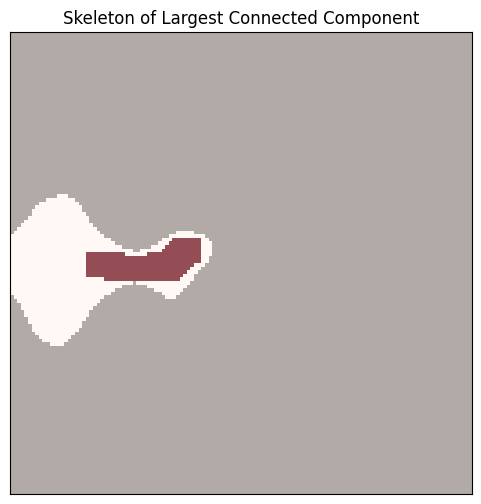

In [ ]:
skeleton_pixels = np.argwhere(trimmed_skeleton)
skeleton_nodes = {tuple(coord): i for i, coord in enumerate(skeleton_pixels)}
num_skeleton_nodes = len(skeleton_pixels)

# Create a graph from the skeleton
skeleton_graph = nx.Graph()
skeleton_graph.add_nodes_from(range(num_skeleton_nodes))
pos_skeleton = {skeleton_nodes[tuple(coord)]: (coord[1], -coord[0]) for coord in skeleton_pixels}

# Add edges based on 8-connectivity
for r, c in skeleton_pixels:
    node_u = skeleton_nodes[(r, c)]
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if dr == 0 and dc == 0:
                continue
            nr, nc = r + dr, c + dc
            if 0 <= nr < img_size and 0 <= nc < img_size and skeleton[nr, nc]:
                if (nr, nc) in skeleton_nodes:
                    node_v = skeleton_nodes[(nr, nc)]
                if node_u < node_v:
                    skeleton_graph.add_edge(node_u, node_v)

# 5. Inflate Skeleton
inflation_radius = 3
inflated_nodes = set()

# Iterate through skeleton nodes and add neighbors within radius
for r, c in skeleton_pixels:
    for dr in range(-inflation_radius, inflation_radius + 1):
        for dc in range(-inflation_radius, inflation_radius + 1):
            nr, nc = r + dr, c + dc
            if 0 <= nr < img_size and 0 <= nc < img_size:
                inflated_nodes.add((nr, nc))

# Create a new binary image with inflated skeleton
inflated_image = np.zeros((img_size, img_size), dtype=bool)
for r, c in inflated_nodes:
    inflated_image[r, c] = True

    # Adjust alpha blending to ensure red pixels are not washed out
# 6. Plot Inflated Skeleton
plt.figure(figsize=(6, 6))
plt.imshow(largest_component, cmap='gray')  # Display the largest component in grayscale
plt.imshow(inflated_image, cmap='Reds', alpha=0.7)  # Use a slightly lower alpha for better visibility
plt.title(f'Skeleton of Largest Connected Component after Trimming and Inflation')
plt.xticks([])
plt.yticks([])
plt.show()

